In [386]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.preprocessing import RobustScaler
import scipy.stats
df = pd.read_csv(r"C:\Users\talon\Downloads\house_prices_train.csv")
#import necessary libraries and load dataset

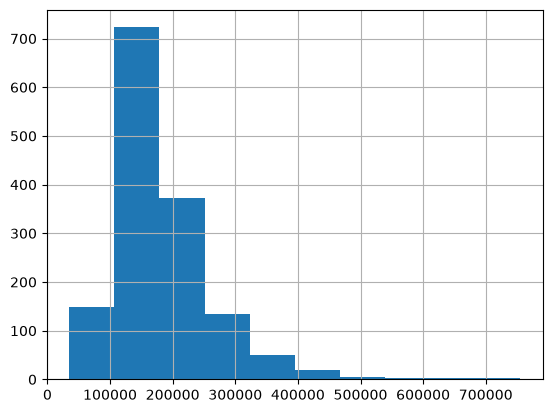

In [387]:
df['SalePrice'].hist()
plt.show()
#view sale price histogram to determine if a log transform is necessary

In [388]:
df['SalePrice'] = np.log(df['SalePrice'])
#log transfrom sale price

In [389]:
print(df.select_dtypes(include='number').columns[df.select_dtypes(include='number').isna().any()])
#find numerical columns with missing data
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].median())
df['GarageYrBlt']=df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())
#fill na values with the median

Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='str')


In [390]:
order = {'TA': 1, 'Gd':2, 'Ex':3}
df['BsmtQual']=df['BsmtQual'].map(order)
df['BsmtQual'] = df['BsmtQual'].astype('Float64')
df['BsmtQual']=df['BsmtQual'].fillna(1)

df['KitchenQual']=df['KitchenQual'].map(order)
df['KitchenQual'] = df['KitchenQual'].astype('Int64')
df['KitchenQual']=df['KitchenQual'].fillna(1)

df['ExterQual']=df['ExterQual'].map(order)
df['ExterQual'] = df['ExterQual'].astype('Int64')
df['ExterQual']=df['ExterQual'].fillna(1)

df['GarageCond']=df['GarageCond'].map(order)
df['GarageCond'] = df['GarageCond'].astype('Int64')
df['GarageCond']=df['GarageCond'].fillna(1)
#Encode important variables


0.1911774884178207
Index([1298, 523, 30, 495, 632], dtype='int64')


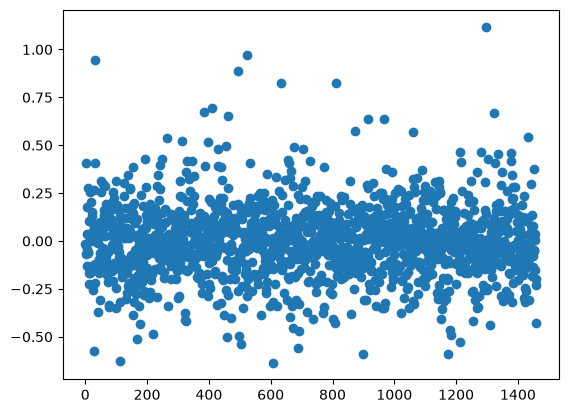

In [391]:
model = sklearn.linear_model.LinearRegression()
model.fit(df[['BsmtQual', 'OverallQual','LotArea','BedroomAbvGr','GarageCars']], df['SalePrice'])
y_pred = model.predict(df[['BsmtQual', 'OverallQual','LotArea','BedroomAbvGr','GarageCars']])
rmse = sklearn.metrics.root_mean_squared_error(df['SalePrice'], y_pred)
plt.scatter(np.arange(1460), (y_pred-df["SalePrice"]))
print(rmse)
print((y_pred-df["SalePrice"]).nlargest(5).index)
#fit linear regression model, oberve data variation, find rmse, and find the 5 worst predictions


Looking at the 5 largest outliers, they all have in common a very small lot area. While There are about 80 factors, this model only used 5, resulting in overcompensation. This caused significant error, especially in houses that were outliers in lot area.

In [392]:
scalar = RobustScaler()
scaled_features = scalar.fit_transform(df[['BsmtQual', 'OverallQual','LotArea','BedroomAbvGr','GarageCars']])

model_2 = sklearn.pipeline.make_pipeline(sklearn.preprocessing.PolynomialFeatures(2), sklearn.linear_model.LinearRegression())
model_2.fit(scaled_features, df['SalePrice'])
y_pred_2 = model_2.predict(scaled_features)
rmse_2 = sklearn.metrics.root_mean_squared_error(df['SalePrice'], y_pred_2)
print(rmse_2)

0.18294790779897577


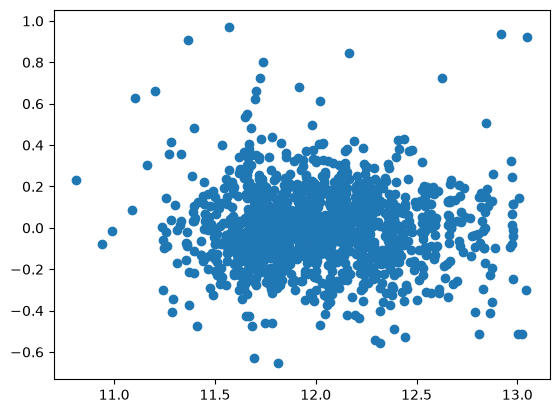

In [393]:
plt.scatter(y_pred_2,(y_pred_2-df["SalePrice"]))

As price increases, the spread does not increase significantly, indicating it is not heteroscedastic. The model does seem to underestimate extremely high priced houses.

In [394]:
ridge_model = sklearn.linear_model.Ridge()
ridge_model.fit(scaled_features, df['SalePrice'])
y_pred_3 = ridge_model.predict(scaled_features)
rmse_3 = sklearn.metrics.root_mean_squared_error(df['SalePrice'], y_pred_3)
print(rmse_3)

lasso_model = sklearn.linear_model.Lasso()
lasso_model.fit(scaled_features, df['SalePrice'])
y_pred_4 = lasso_model.predict(scaled_features)
rmse_4 = sklearn.metrics.root_mean_squared_error(df['SalePrice'], y_pred_4)
print(rmse_4)
# use lasso and ridge model on same data to compare results

0.1911777772302223
0.39931504624370256


In [395]:
plain_weights = []
ridge_weights = []
lasso_weights = []
for i in range(5):
    plain_weights.append(float(model.coef_[i]))
    ridge_weights.append(float(ridge_model.coef_[i]))
    lasso_weights.append(float(lasso_model.coef_[i]))
print("Normal Linear Regression: Weights: ", plain_weights, "Bias: ", float(model.intercept_), "RSME: ", rmse)
print("Ridge Linear Regression: Weights: ", ridge_weights, "Bias: ", float(ridge_model.intercept_), "RSME: ", rmse_3)
print("Lasso Linear Regression: Weights: ", lasso_weights, "Bias: ", float(lasso_model.intercept_), "RSME: ", rmse_4)

Normal Linear Regression: Weights:  [0.10764460310533316, 0.1534807117635941, 5.429821761967814e-06, 0.06421985630196143, 0.12621697621322808] Bias:  10.452644265756746 RSME:  0.1911774884178207
Ridge Linear Regression: Weights:  [0.1078712713013528, 0.3063171466709425, 0.02198792160167953, 0.06421196332987528, 0.12631203174349642] Bias:  12.085522003157351 RSME:  0.1911777772302223
Lasso Linear Regression: Weights:  [0.0, 0.0, 0.0, 0.0, 0.0] Bias:  12.024050901109383 RSME:  0.39931504624370256


The normal linear regression model seems to be the most successful model in terms of rmse. However, by adjusting the alpha parameter for Lasso and ridge, they both approach the same rmse as alpha decreases. Interestingly, Lasso only zeroed out all the weights on very high numbers for alpha (which did not seem to be a good approach).

((array([-3.30513952, -3.04793228, -2.90489705, ...,  2.90489705,
          3.04793228,  3.30513952], shape=(1460,)),
  array([-0.65122377, -0.62987043, -0.55828559, ...,  0.92218592,
          0.93637092,  0.97276636], shape=(1460,))),
 (np.float64(0.17998576684491902),
  np.float64(1.55618370932994e-15),
  np.float64(0.9818485376960513)))

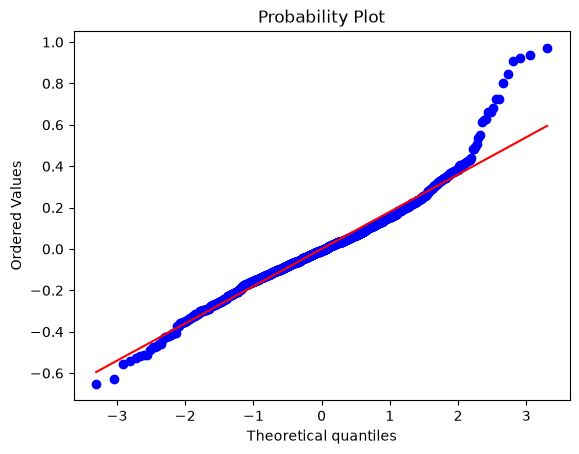

In [396]:
scipy.stats.probplot(y_pred_2-df["SalePrice"], plot=plt)
# A Q-Q plot of residuals

The QQ plot reveals that the data used has heavy tails, meaning it contains more extreme values than expected. Points in the middle percentiles exhibit close to a normal distribution, while those on the end are skewed. Removing the log transform made the tails much worse on both the high and low end.